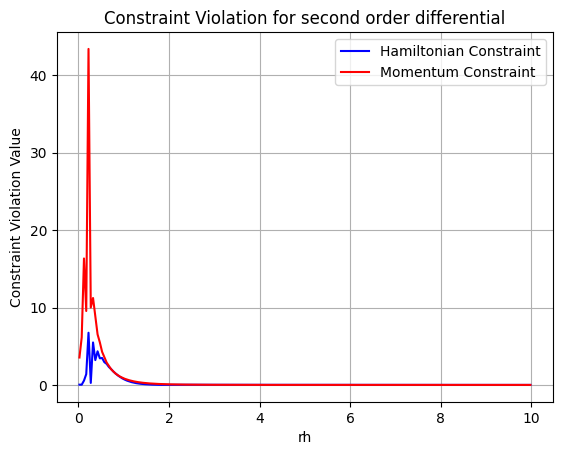

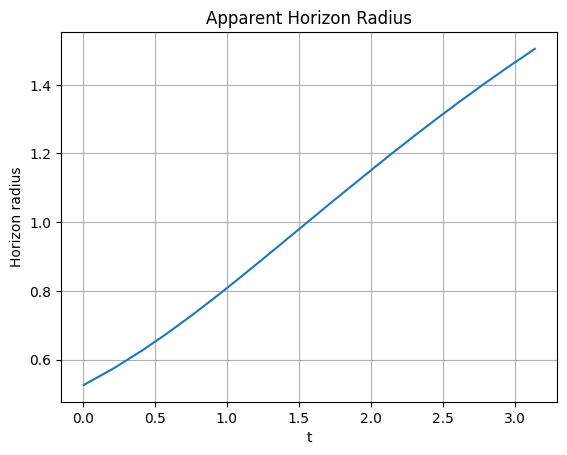

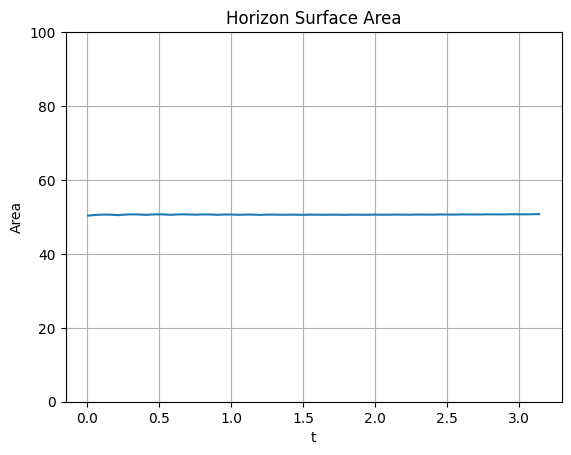

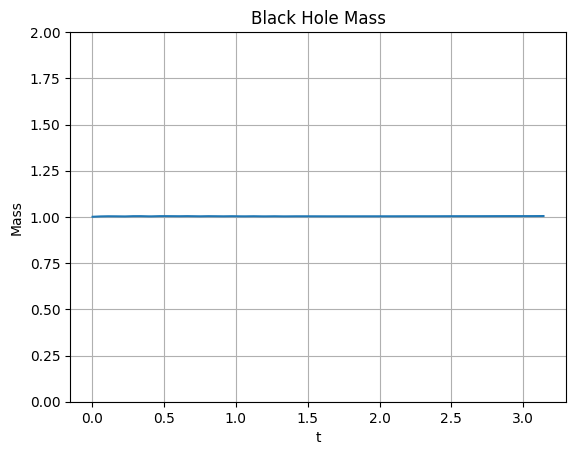

In [ ]:
#@title Debugged for the right formula.
import numpy as np
import matplotlib.pyplot as plt

#values
N = 200
M = 1.0

dr = 0.05
dt = 0.1*dr

t_max = np.pi*M
steps = int(t_max/dt)

#staggered grid
r_j = (0.5 + np.arange(N))*dr

#Given Data
A_bar = np.ones(N)
B_bar = np.ones(N)

DA_bar = np.zeros(N)
DB_bar = np.zeros(N)

KA = np.zeros(N)
KB = np.zeros(N)

alpha = np.ones(N)

#conformal factor
psi = 1 + M/(2*r_j)

#regularization term
E = 4*np.gradient(np.log(psi),dr)

#Boundary Condition
def boundary(f, parity):

    n = len(f)
    g = np.zeros(n+2)

    g[1:-1] = f

    if parity == "even":
        g[0] = f[0]
    else:
        g[0] = -f[0]

    g[-1] = g[-2]

    return g

#Finite Difference Second Order
def d_dr(f, parity):

    g = boundary(f, parity)

    df = (g[2:] - g[:-2])/(2*dr)

    return df

#constraints
def hamiltonian_constraint(A_bar, DA_bar, DB_bar, KA, KB):

  A  = A_bar * psi**4
  DA = DA_bar + E
  DB = DB_bar + E

  dDB_dr = d_dr(DB, 'odd')

  Ha = ((-dDB_dr - 0.5 * DB**2 + 0.5 * DA * DB + (DA - 2.0 * DB) / r_j) / A + KA**2 + 2.0 * KB**2)

  return Ha

def momentum_constraint(DA_bar, DB_bar, KA, KB):

  DA = DA_bar + E
  DB = DB_bar + E

  dKB_dr = d_dr(KB, 'even')

  p = (dKB_dr+ (KB - KA) / r_j + 1.5 * DB * KB - 0.5 * DA * KA)

  return p

#ADM
def ADM_rhs(state):

    A_bar,B_bar,DA_bar,DB_bar,KA,KB,alpha = state

    A = A_bar*psi**4
    B = B_bar*psi**4

    DA = DA_bar + E
    DB = DB_bar + E

    alpha = np.maximum(alpha,1e-12)

    Dalpha = d_dr(np.log(alpha),'even')

    K = KA + 2*KB

    dKA = d_dr(KA,'even')
    dKB = d_dr(KB,'even')
    dDB = d_dr(DB,'even')

    d_term = d_dr(Dalpha + DB,'even')

    #metric evolution
    dAbar = -2*alpha*A_bar*KA
    dBbar = -2*alpha*B_bar*KB

    #auxiliary variables
    dDAbar = -2*alpha*(KA*Dalpha + dKA)
    dDBbar = -2*alpha*(KB*Dalpha + dKB)

    #extrinsic curvature
    dKA_dt = -(alpha/A)*(d_term + Dalpha**2-0.5*Dalpha*DA+0.5*DB**2-0.5*DA*DB-(DA-2*DB)/r_j)+alpha*KA*K

    dKB_dt = -(alpha/(2*A))*(dDB+Dalpha*DB+DB**2-0.5*DA*DB-(DA-2*Dalpha-4*DB)/r_j-2*(A-B)/(r_j**2 * B))+alpha*KB*K

    #1+log slicing
    dalpha = -2*alpha*K

    return np.array([dAbar,dBbar,dDAbar,dDBbar,dKA_dt,dKB_dt,dalpha])

#RK4
def rk4(state):

    k1 = ADM_rhs(state)
    k2 = ADM_rhs(state + 0.5*dt*k1)
    k3 = ADM_rhs(state + 0.5*dt*k2)
    k4 = ADM_rhs(state + dt*k3)

    return state + dt/6*(k1 + 2*k2 + 2*k3 + k4)

#Apparent Horizon
def horizon(A_bar,B_bar,DB_bar,KB):

    A = A_bar * psi**4
    DB = DB_bar + E
    B = B_bar * psi**4

    H = (1/np.sqrt(A))*((2/r_j) + (d_dr(B,'even')/B)) - 2*KB

    return H

def find_horizon(H):

    for i in range(len(H)-1):

      if r_j[i] < 0.1:
            continue


      if H[i]*H[i+1] < 0:

          return np.interp(0,[H[i],H[i+1]],[r_j[i],r_j[i+1]])

    return None


#Evolution Loop
state = np.stack([A_bar, B_bar, DA_bar, DB_bar, KA, KB, alpha]).astype(float)

t = 0

rh_list=[]
Sh_list=[]
M_list=[]
time_list=[]

for n in range(steps):

    state = rk4(state)

    A_bar,B_bar,DA_bar,DB_bar,KA,KB,alpha = state

    t += dt
    Hc = hamiltonian_constraint(A_bar, DA_bar, DB_bar, KA, KB)
    Mc = momentum_constraint(DA_bar, DB_bar, KA, KB)

    H = horizon(A_bar,B_bar,DB_bar,KB)

    rh = find_horizon(H)

    if rh is not None:

        psi_h = np.interp(rh,r_j,psi)
        Bbar_h = np.interp(rh,r_j,B_bar)

        B_h = Bbar_h * psi_h**4

        Sh = 4*np.pi * rh**2 * B_h
        M_h = np.sqrt(Sh/(16*np.pi))

        rh_list.append(rh)
        Sh_list.append(Sh)
        M_list.append(M_h)
        time_list.append(t)

#plot
plt.figure()
plt.plot(r_j, np.abs(Hc), '-b', label = 'Hamiltonian Constraint')
plt.plot(r_j, np.abs(Mc), '-r', label = 'Momentum Constraint')
plt.legend()
plt.xlabel("rh")
plt.ylabel(r"Constraint Violation Value")
plt.title("Constraint Violation for second order differential")
plt.grid()

plt.figure()
plt.plot(time_list,rh_list)
plt.xlabel("t")
plt.ylabel("Horizon radius")
plt.title("Apparent Horizon Radius")
plt.grid()

plt.figure()
plt.plot(time_list,Sh_list)
plt.xlabel("t")
plt.ylabel("Area")
plt.ylim(0,100)
plt.title("Horizon Surface Area")
plt.grid()

plt.figure()
plt.plot(time_list,M_list)
plt.xlabel("t")
plt.ylim(0,2)
plt.ylabel("Mass")
plt.title("Black Hole Mass")
plt.grid()
plt.show()